In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../../Datasets_MLmodels/Chosen_Datasets/fmcg_sales.csv")
df.head()

,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1000, 10)

Columns:
['Date', 'Product_Category', 'Sales_Volume', 'Price', 'Promotion', 'Store_Location', 'Weekday', 'Supplier_Cost', 'Replenishment_Lead_Time', 'Stock_Level']

Data Types:
Date                        object
Product_Category            object
Sales_Volume                 int64
Price                      float64
Promotion                    int64
Store_Location              object
Weekday                      int64
Supplier_Cost              float64
Replenishment_Lead_Time      int64
Stock_Level                  int64
dtype: object


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1000 non-null   object 
 1   Product_Category         1000 non-null   object 
 2   Sales_Volume             1000 non-null   int64  
 3   Price                    1000 non-null   float64
 4   Promotion                1000 non-null   int64  
 5   Store_Location           1000 non-null   object 
 6   Weekday                  1000 non-null   int64  
 7   Supplier_Cost            1000 non-null   float64
 8   Replenishment_Lead_Time  1000 non-null   int64  
 9   Stock_Level              1000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB


In [6]:
df.describe(include="all")

,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
count,1000,1000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000
unique,1000,5,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,2022-01-01,Beverages,NaN,NaN,NaN,Urban,NaN,NaN,NaN,NaN
freq,1,210,NaN,NaN,NaN,342,NaN,NaN,NaN,NaN
mean,NaN,NaN,1048.781000,10.362358,0.491000,NaN,2.999000,7.552047,4.970000,266.494000
std,NaN,NaN,539.688298,5.420627,0.500169,NaN,2.001751,4.163729,2.589944,130.560078
min,NaN,NaN,101.000000,1.003580,0.000000,NaN,0.000000,0.500445,1.000000,50.000000
25%,NaN,NaN,591.750000,5.541108,0.000000,NaN,1.000000,3.887763,3.000000,152.000000
50%,NaN,NaN,1064.500000,10.404366,0.000000,NaN,3.000000,7.422058,5.000000,260.000000
75%,NaN,NaN,1489.000000,15.054035,1.000000,NaN,5.000000,11.099853,7.000000,376.000000


In [7]:
missing_values = df.isnull().sum()

print(missing_values)

Date                       0
Product_Category           0
Sales_Volume               0
Price                      0
Promotion                  0
Store_Location             0
Weekday                    0
Supplier_Cost              0
Replenishment_Lead_Time    0
Stock_Level                0
dtype: int64


In [8]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_percentage

Date                       0.0
Product_Category           0.0
Sales_Volume               0.0
Price                      0.0
Promotion                  0.0
Store_Location             0.0
Weekday                    0.0
Supplier_Cost              0.0
Replenishment_Lead_Time    0.0
Stock_Level                0.0
dtype: float64

In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1000, 10)


In [11]:
df.columns

Index(['Date', 'Product_Category', 'Sales_Volume', 'Price', 'Promotion',
       'Store_Location', 'Weekday', 'Supplier_Cost', 'Replenishment_Lead_Time',
       'Stock_Level'],
      dtype='object')

In [12]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [13]:
print(df["Date"].min())
print(df["Date"].max())

2022-01-01 00:00:00
2024-09-26 00:00:00


In [14]:
print(df["Date"].isnull().sum())

0


In [15]:
df = df.sort_values("Date").reset_index(drop=True)

In [16]:
df.head()

,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334


In [17]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2022-01-01 00:00:00
End Date: 2024-09-26 00:00:00


In [18]:
print("Unique Dates:", df["Date"].nunique())

Unique Dates: 1000


In [19]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

In [20]:
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

In [21]:
df.head()

,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level,Year,Month,Day,DayOfWeek,WeekOfYear,Quarter,IsWeekend
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207,2022,1,1,5,52,1,1
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253,2022,1,2,6,52,1,1
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245,2022,1,3,0,1,1,0
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265,2022,1,4,1,1,1,0
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334,2022,1,5,2,1,1,0


In [22]:
df.select_dtypes(include=np.number).columns

Index(['Sales_Volume', 'Price', 'Promotion', 'Weekday', 'Supplier_Cost',
       'Replenishment_Lead_Time', 'Stock_Level', 'Year', 'Month', 'Day',
       'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend'],
      dtype='object')

In [23]:
TARGET = "Sales_Volume"

In [24]:
print(df[TARGET].describe())

count    1000.000000
mean     1048.781000
std       539.688298
min       101.000000
25%       591.750000
50%      1064.500000
75%      1489.000000
max      1997.000000
Name: Sales_Volume, dtype: float64


In [25]:
print("Minimum demand:", df[TARGET].min())
print("Maximum demand:", df[TARGET].max())
print("Average demand:", df[TARGET].mean())
print("Median demand:", df[TARGET].median())

Minimum demand: 101
Maximum demand: 1997
Average demand: 1048.781
Median demand: 1064.5


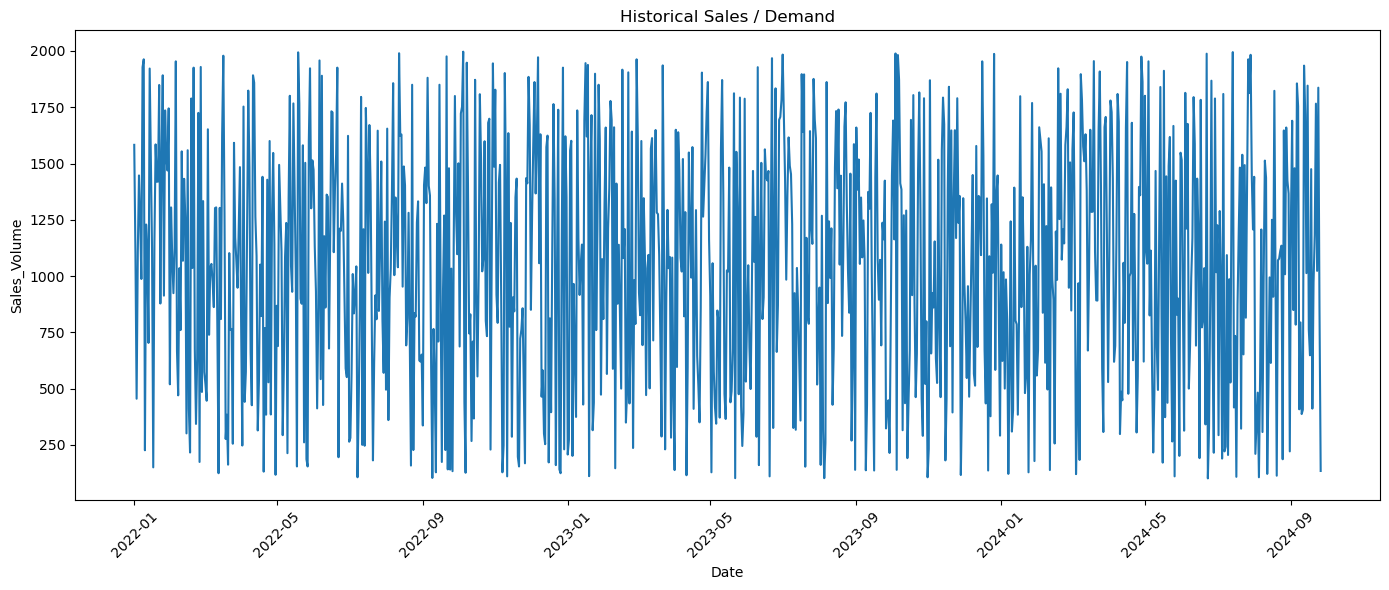

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df[TARGET]
)

plt.title("Historical Sales / Demand")
plt.xlabel("Date")
plt.ylabel(TARGET)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [27]:
monthly_demand = (df.set_index("Date")[TARGET].resample("ME").sum())

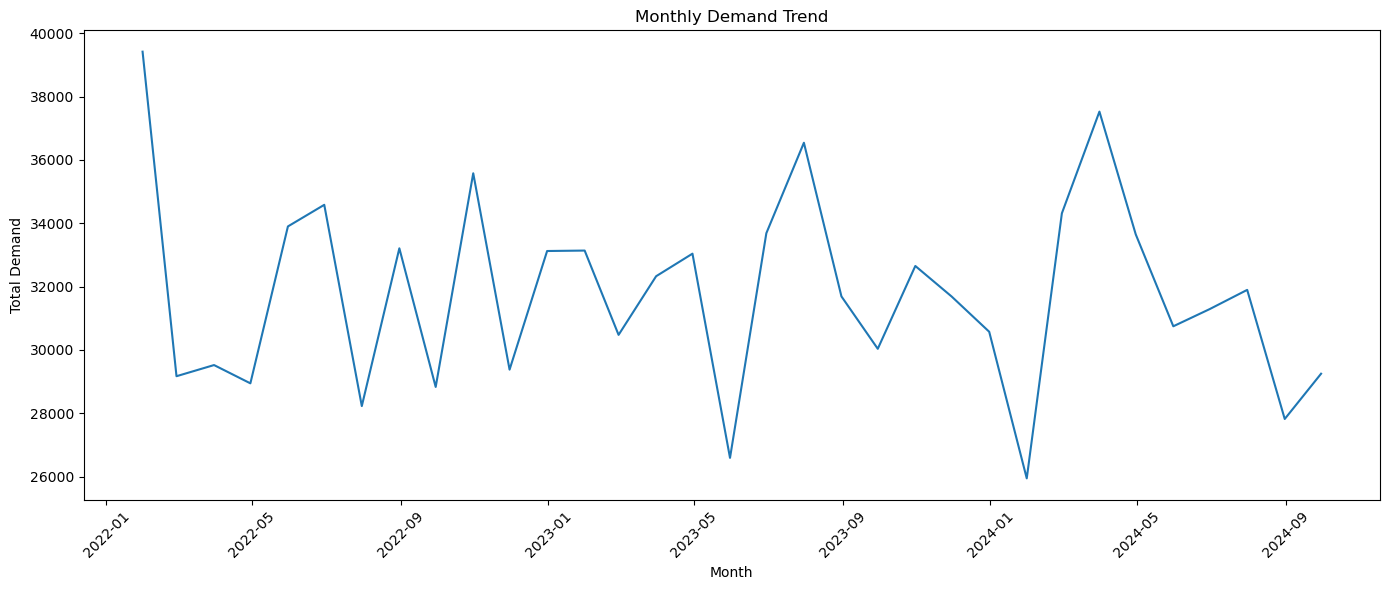

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand.index,
    monthly_demand.values
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [29]:
monthly_pattern = (df.groupby("Month")[TARGET].mean())

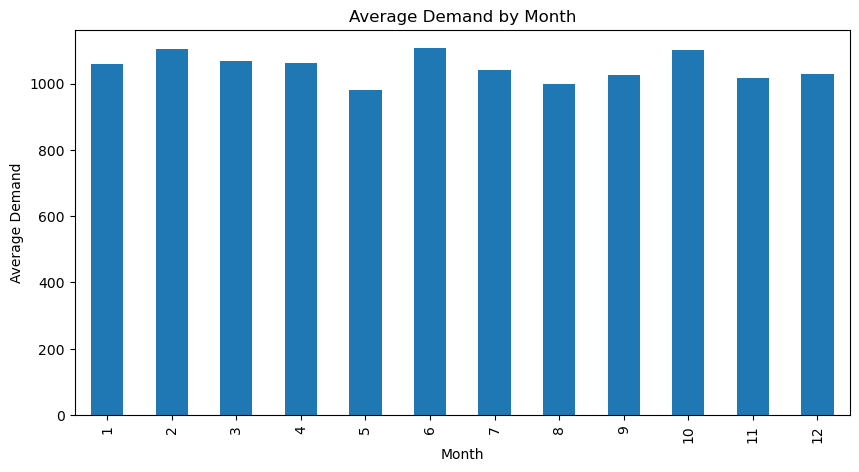

In [30]:
plt.figure(figsize=(10, 5))

monthly_pattern.plot(
    kind="bar"
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.show()

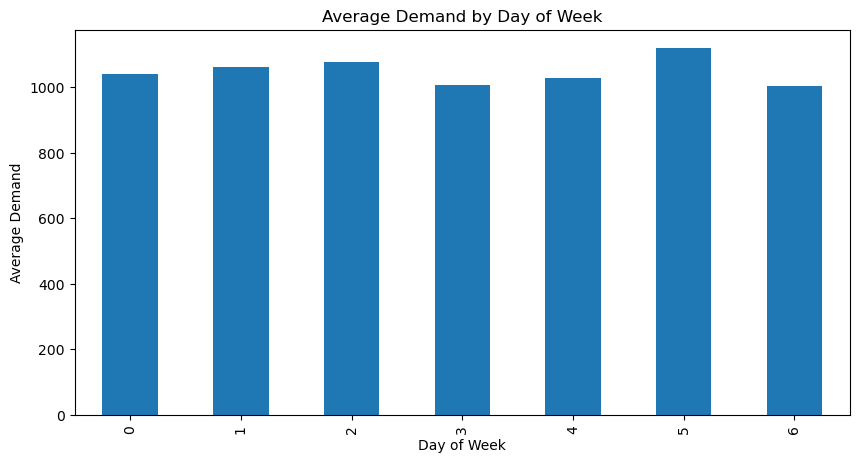

In [31]:
weekday_pattern = (df.groupby("DayOfWeek")[TARGET].mean())
plt.figure(figsize=(10, 5))

weekday_pattern.plot(
    kind="bar"
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")

plt.show()

In [32]:
df.columns

Index(['Date', 'Product_Category', 'Sales_Volume', 'Price', 'Promotion',
       'Store_Location', 'Weekday', 'Supplier_Cost', 'Replenishment_Lead_Time',
       'Stock_Level', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear',
       'Quarter', 'IsWeekend'],
      dtype='object')

In [33]:
promotion_effect = (df.groupby("Promotion")[TARGET].mean())
promotion_effect

Promotion
0    1036.170923
1    1061.853360
Name: Sales_Volume, dtype: float64

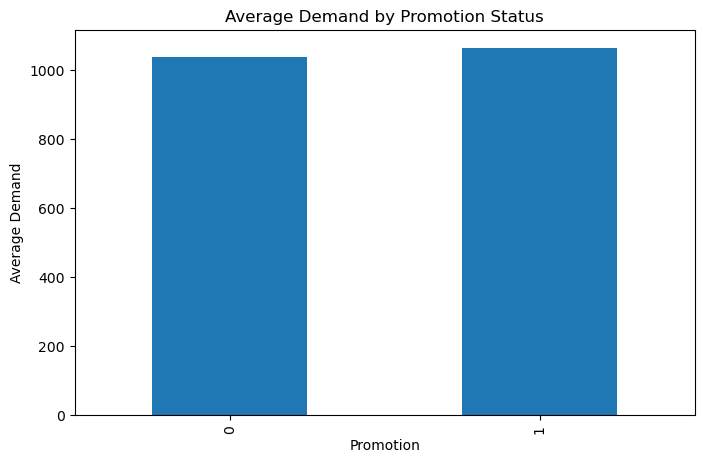

In [34]:
promotion_effect.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Demand by Promotion Status")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")

plt.show()

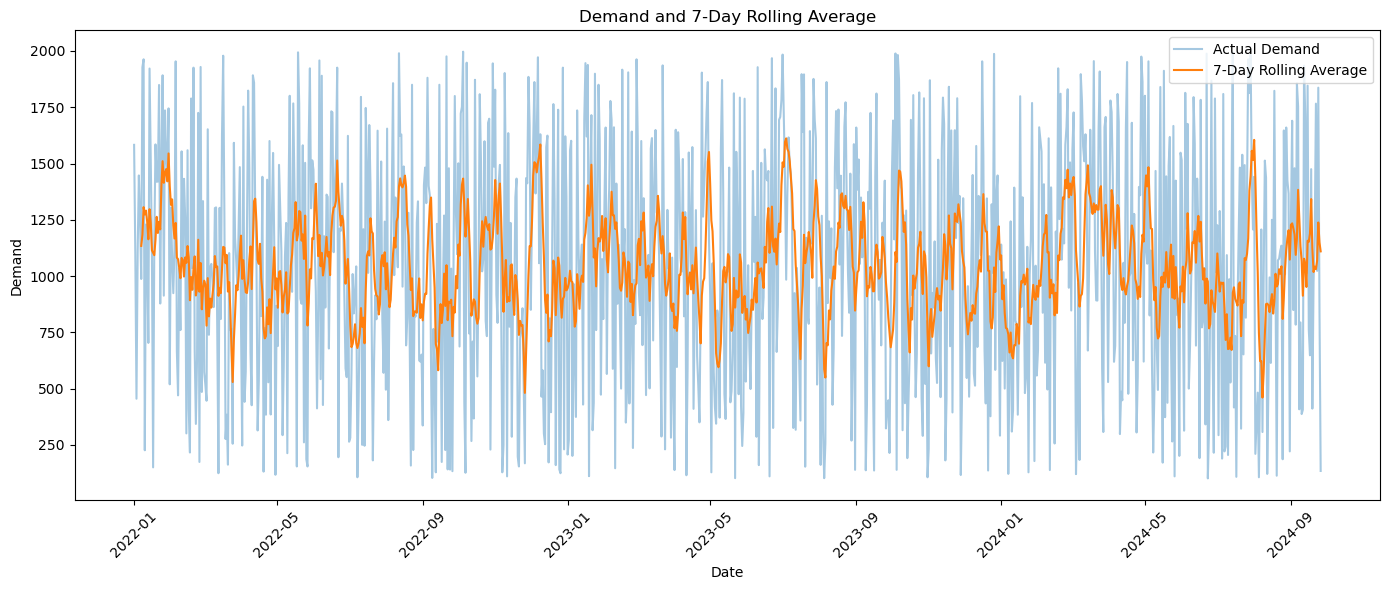

In [35]:
df["Rolling_7"] = (df[TARGET].rolling(window=7).mean())
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df[TARGET],
    alpha=0.4,
    label="Actual Demand"
)

plt.plot(
    df["Date"],
    df["Rolling_7"],
    label="7-Day Rolling Average"
)

plt.title("Demand and 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
ts = (df.groupby("Date")[TARGET].sum().sort_index())
ts.head()

Date
2022-01-01    1583
2022-01-02    1103
2022-01-03     455
2022-01-04    1107
2022-01-05    1447
Name: Sales_Volume, dtype: int64

In [37]:
ts.shape

(1000,)

In [38]:
split_index = int(
    len(ts) * 0.80
)

train = ts.iloc[:split_index]
test = ts.iloc[split_index:]

In [39]:
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 800
Testing observations: 200

Training period:
2022-01-01 00:00:00 to 2024-03-10 00:00:00

Testing period:
2024-03-11 00:00:00 to 2024-09-26 00:00:00


In [40]:
last_value = train.iloc[-1]

naive_forecast = np.repeat(
    last_value,
    len(test)
)

In [41]:
naive_mae = mean_absolute_error(
    test,
    naive_forecast
)
naive_rmse = np.sqrt(
    mean_squared_error(test, naive_forecast)
)

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

Naive MAE: 621.43
Naive RMSE: 761.2323364124779


In [42]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

warnings.filterwarnings("ignore")

In [43]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

In [44]:
hw_fit = hw_model.fit(optimized=True)

In [45]:
hw_forecast = hw_fit.forecast(len(test))

In [46]:
hw_mae = mean_absolute_error(
    test,
    hw_forecast
)
hw_rmse = np.sqrt(
    mean_squared_error(test, hw_forecast)
)

print("Holt-Winters MAE:", hw_mae)
print("Holt-Winters RMSE:", hw_rmse)

Holt-Winters MAE: 473.6272344272542
Holt-Winters RMSE: 553.3776633233052


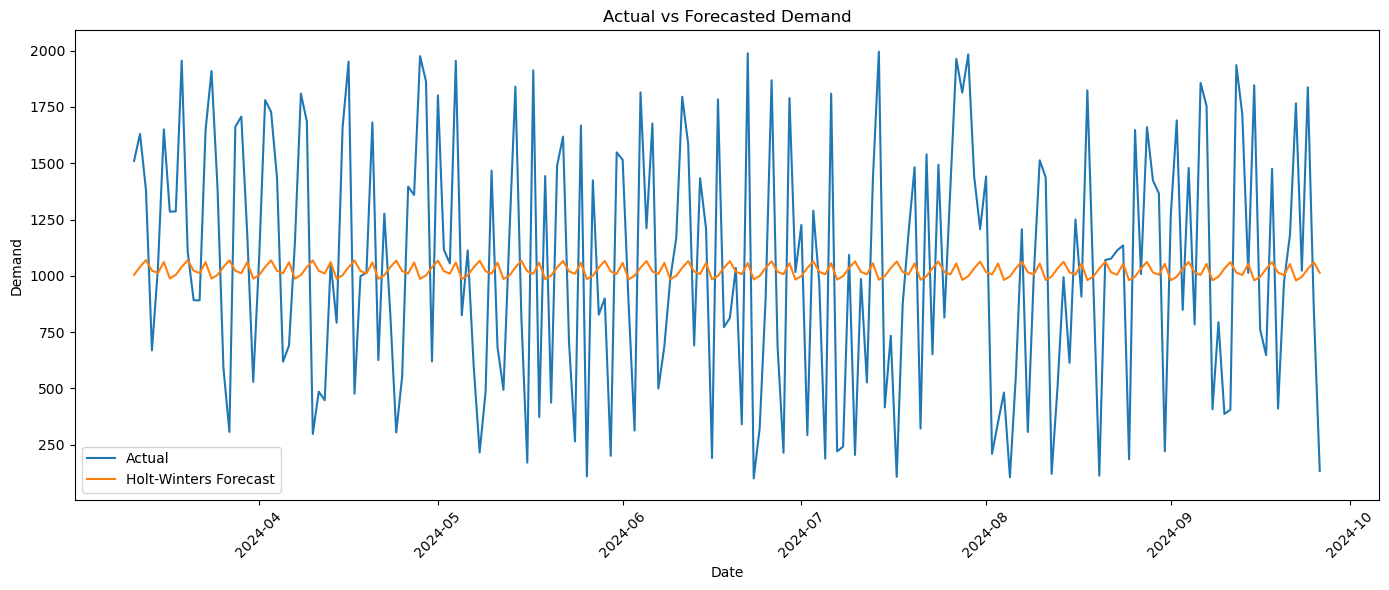

In [47]:
plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    hw_forecast,
    label="Holt-Winters Forecast"
)

plt.title("Actual vs Forecasted Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [48]:
results = pd.DataFrame({
    "Model": ["Naive", "Holt-Winters"],
    "MAE": [naive_mae, hw_mae],
    "RMSE": [naive_rmse, hw_rmse]
})

results

,Model,MAE,RMSE
0,Naive,621.430000,761.232336
1,Holt-Winters,473.627234,553.377663


In [49]:
mape = (
    np.mean(
        np.abs((test - hw_forecast) / test.replace(0, np.nan))
    ) * 100
)

print("MAPE:", mape)

MAPE: 98.31880876012002


In [50]:
future_forecast = hw_forecast.mean()

print("Average Forecasted Demand:", future_forecast)

Average Forecasted Demand: 1024.0685307063072


In [52]:
forecast_results = pd.DataFrame({
    "Date": test.index,
    "Actual_Demand": test.values,
    "Forecasted_Demand": hw_forecast.values
})

forecast_results.to_csv("../../outputs/capstone03_forecast_results.csv",index=False)